# Import all requirements

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [49]:
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

CSV = "logistics_predictive_maintenanceV2.csv"
df = pd.read_csv(CSV)
print("shape:", df.shape)

shape: (250000, 50)


In [50]:
df.sample(5)

,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Last_Maintenance_Date,Maintenance_Type,Brake_Condition,Maintenance_Severity,Maintenance_Severity_ID,Maintenance_Required,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
22543,22544,Ford F-150,Heavy Truck,2015,Highway Freight,Clear,Mountainous,OBD-II/CAN,Fleet_IoT_Node,ARM_Cortex_A72,15064.8500,20000,10573.2666,91.8793,34.5100,9.1231,80.9655,0.9557,88.2319,0,0,0,24.7481,0.0016,411.2584,411.2584,2.9458,0.1361,132,2024-08-22,Routine Inspection,Good,Normal,0,0,0.5287,0.6848,2.6624,411.2584,0.0,1.7197,4.1873,36.5423,0.2510,1,Train,1,Non-IID Dirichlet alpha=0.5,2,200
242091,242092,Ford F-150,Light Truck,2013,Urban Delivery,Clear,Mountainous,OBD-II/CAN,OBD_Gateway,ARM_Cortex_A53,17801.4231,2500,1982.3466,116.2757,29.3961,18.2816,49.1862,5.7254,57.8569,2,1,4,61.9268,0.0466,2760.8595,2760.8595,17.7071,0.5235,418,2023-11-10,Engine Overhaul,Poor,Major Maintenance,2,1,0.7929,0.6847,3.9555,4141.2892,2.8,2.7741,27.2780,6.4454,0.6015,1,Train,4,Non-IID Dirichlet alpha=0.5,2,200
33041,33042,Mercedes Actros,Electric Truck,2010,Cold-Chain Route,Foggy,Rough,OBD-II/CAN,Edge_Telematics_Box,Automotive_ECU,21649.8042,2500,1676.2020,86.7164,35.5266,6.2669,77.6011,1.6660,73.4906,0,0,1,39.5890,0.0135,186.3323,186.3323,2.4380,0.1314,77,2024-10-16,Routine Inspection,Good,Normal,0,0,0.6705,0.6766,2.4409,186.3323,0.2,2.5967,3.2613,115.5690,0.2432,1,Train,3,Non-IID Dirichlet alpha=0.5,2,200
212450,212451,Ford F-150,Light Truck,2010,Cold-Chain Route,Hot,Rough,OBD-II/CAN,Embedded_TCU,ARM_Cortex_A53,21812.8671,10000,5822.6178,96.8642,31.4549,9.2320,76.7715,1.0333,82.3091,0,1,0,22.3108,0.0000,569.1364,569.1364,1.7997,0.1070,37,2024-11-25,Tire Rotation,Good,Normal,0,0,0.5823,0.6817,3.0795,569.1364,1.0,2.4615,2.7872,38.2590,0.2669,1,Validation,3,Non-IID Dirichlet alpha=0.5,2,200
76578,76579,Scania R-Series,Light Truck,2023,Intercity Logistics,Hot,Smooth,CAN-FD/Telematics,OBD_Gateway,ARM_Cortex_A72,3774.4913,1500,658.2159,98.1946,37.3007,8.0789,79.9168,1.1676,91.7730,0,1,1,29.6139,0.0074,245.3924,245.3924,1.8894,0.1131,76,2024-10-17,Routine Inspection,Good,Normal,0,0,0.4388,0.6291,2.6325,245.3924,1.2,0.5765,2.8032,15.3190,0.2377,1,Validation,3,Non-IID Dirichlet alpha=0.5,2,200


# Understand the Data

In [51]:
df.shape

(250000, 50)

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Vehicle_ID                     250000 non-null  int64  
 1   Make_and_Model                 250000 non-null  str    
 2   Vehicle_Type                   250000 non-null  str    
 3   Year_of_Manufacture            250000 non-null  int64  
 4   Route_Info                     250000 non-null  str    
 5   Weather_Conditions             250000 non-null  str    
 6   Road_Conditions                250000 non-null  str    
 7   Communication_Interface        250000 non-null  str    
 8   Telematics_Gateway             250000 non-null  str    
 9   Edge_Device_Class              250000 non-null  str    
 10  Usage_Hours                    250000 non-null  float64
 11  Load_Capacity                  250000 non-null  int64  
 12  Actual_Load                    250000 non

Fix Date data-type

In [53]:
df['Last_Maintenance_Date'] = pd.to_datetime(df['Last_Maintenance_Date'])

In [54]:
df.describe()

,Vehicle_ID,Year_of_Manufacture,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Last_Maintenance_Date,Maintenance_Severity_ID,Maintenance_Required,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,FL_Client_ID,Local_Epochs_Per_Round,Communication_Rounds
count,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.0,250000.000000,250000.0,250000.0
mean,125000.500000,2017.001532,11599.770357,10190.01000,6346.029736,93.202062,33.397201,9.596477,76.481665,2.042091,78.969756,0.607068,0.750020,0.890128,41.916362,0.012810,765.309199,765.309199,3.127070,0.188106,183.060796,2024-07-01 22:32:27.225599,0.400000,0.300000,0.622546,0.61011,2.849918,1058.767925,1.231580,1.574489,5.239038,33.223217,0.285302,1.0,2.645560,2.0,200.0
min,1.000000,2010.000000,300.000000,1500.00000,525.028400,61.206400,16.875200,4.000000,20.095500,0.000000,20.000000,0.000000,0.000000,0.000000,5.000000,0.000000,80.000000,80.000000,0.000000,0.020000,30.000000,2023-01-02 00:00:00,0.000000,0.000000,0.350000,0.06330,1.619100,80.000000,0.000000,0.061700,0.109800,0.060400,0.038000,1.0,1.000000,2.0,200.0
25%,62500.750000,2013.000000,6164.741925,5000.00000,2039.542650,85.787600,31.513900,7.511100,68.343625,1.011000,72.457425,0.000000,0.000000,0.000000,31.930600,0.004300,276.042550,276.042550,0.705700,0.105100,84.000000,2024-05-19 00:00:00,0.000000,0.000000,0.493300,0.58560,2.430100,283.411650,0.000000,1.016800,1.640700,9.009875,0.188500,1.0,1.000000,2.0,200.0
50%,125000.500000,2017.000000,11610.537150,10000.00000,5077.010500,91.135650,33.962100,8.696300,80.162200,1.464600,82.728100,0.000000,0.000000,0.000000,38.912350,0.007800,386.331200,386.331200,1.432100,0.141700,138.000000,2024-08-16 00:00:00,0.000000,0.000000,0.614600,0.64440,2.647300,400.253450,0.200000,1.575700,2.448300,23.203900,0.222100,1.0,3.000000,2.0,200.0
75%,187500.250000,2021.000000,17042.005500,15000.00000,9456.293225,98.968125,35.841500,10.974000,86.584325,2.451900,88.199525,1.000000,1.000000,1.000000,48.796225,0.014400,863.075750,863.075750,3.809800,0.234200,227.000000,2024-10-09 00:00:00,1.000000,1.000000,0.722200,0.67440,3.089025,1031.561550,1.500000,2.118100,7.002700,46.523325,0.370500,1.0,4.000000,2.0,200.0
max,250000.000000,2024.000000,24350.832900,25000.00000,27496.171800,130.000000,44.282600,23.820200,100.000000,10.704300,100.000000,10.000000,13.000000,16.000000,117.841400,0.124100,6434.800500,6434.800500,29.445000,0.871000,730.000000,2024-12-02 00:00:00,2.000000,1.000000,1.100000,1.00250,7.403500,16662.370700,16.500000,3.820500,38.908800,289.349700,0.837000,1.0,4.000000,2.0,200.0
std,72168.927986,4.318923,6295.169412,7378.42117,5048.893723,10.446833,3.523209,3.043484,14.056945,1.651715,13.213932,1.133718,1.478135,1.612021,14.575371,0.014405,932.205960,932.205960,4.259782,0.128531,149.133783,NaN,0.663326,0.458258,0.165183,0.10581,0.629637,1675.240794,2.107289,0.688476,6.283295,34.516317,0.147486,0.0,1.230572,0.0,0.0


In [55]:
df.isnull().sum()

Vehicle_ID                       0
Make_and_Model                   0
Vehicle_Type                     0
Year_of_Manufacture              0
Route_Info                       0
Weather_Conditions               0
Road_Conditions                  0
Communication_Interface          0
Telematics_Gateway               0
Edge_Device_Class                0
Usage_Hours                      0
Load_Capacity                    0
Actual_Load                      0
Engine_Temperature               0
Tire_Pressure                    0
Fuel_Consumption                 0
Battery_Status                   0
Vibration_Levels                 0
Oil_Quality                      0
Failure_History                  0
Anomalies_Detected               0
Diagnostic_Trouble_Code_Count    0
CAN_Message_Rate_Hz              0
Sensor_Packet_Loss_Rate          0
Maintenance_Cost                 0
Historical_Maintenance_Cost      0
Downtime_Maintenance             0
Impact_on_Efficiency             0
Days_Since_Last_Main

In [56]:
df.duplicated().sum()

np.int64(0)

# Categorize the columns

## Removing unwanted columns

In [57]:
df[['Maintenance_Required', 'Load_Capacity', 'Actual_Load', 'PCR']].corr()

,Maintenance_Required,Load_Capacity,Actual_Load,PCR
Maintenance_Required,1.000000,0.000088,0.222758,0.668414
Load_Capacity,0.000088,1.000000,0.911354,0.001868
Actual_Load,0.222758,0.911354,1.000000,0.334937
PCR,0.668414,0.001868,0.334937,1.000000


No of unique values in 'Pre_Event_Record' Column:  1


,Maintenance_Required,Predictive_Score,Maintenance_Severity_ID
Maintenance_Required,1.000000,0.864786,0.921132
Predictive_Score,0.864786,1.000000,0.963906
Maintenance_Severity_ID,0.921132,0.963906,1.000000


<Axes: xlabel='Predictive_Score', ylabel='Count'>

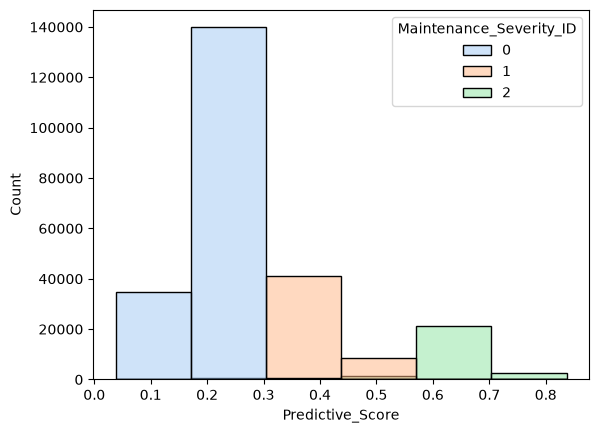

In [58]:
print("No of unique values in 'Pre_Event_Record' Column: ", df['Pre_Event_Record'].nunique())
display(df[['Maintenance_Required','Predictive_Score', 'Maintenance_Severity_ID']].corr())

sns.histplot( x = df['Predictive_Score'], hue=df['Maintenance_Severity_ID'], bins=6, palette="pastel")

In [59]:
# Feature used to extract new featues > No need
OPTIMISED = ['Load_Capacity', 'Actual_Load']

#Does not take any part in final prediction 
USELESS = ['Communication_Interface','Telematics_Gateway','Edge_Device_Class', # Useless data about IoT Device
           'Pre_Event_Record', 'Predictive_Score']

# Features for training/ Testing, model training
FL = ['FL_Client_ID', 'Partition_Type', 'Local_Epochs_Per_Round', 'Communication_Rounds']

to_drop =  OPTIMISED + USELESS  + FL # Pre_Event_Record contain one one value
df.drop(to_drop, axis = 1, inplace = True)

## Categorise Features

In [60]:
df.nunique()

Vehicle_ID                       250000
Make_and_Model                        8
Vehicle_Type                          5
Year_of_Manufacture                  15
Route_Info                            5
Weather_Conditions                    6
Road_Conditions                       5
Usage_Hours                      249199
Engine_Temperature               178710
Tire_Pressure                    111961
Fuel_Consumption                  95782
Battery_Status                   188946
Vibration_Levels                  58297
Oil_Quality                      182536
Failure_History                      11
Anomalies_Detected                   14
Diagnostic_Trouble_Code_Count        17
CAN_Message_Rate_Hz              192551
Sensor_Packet_Loss_Rate             988
Maintenance_Cost                 241458
Historical_Maintenance_Cost      241458
Downtime_Maintenance              80100
Impact_on_Efficiency               6949
Days_Since_Last_Maintenance         701
Last_Maintenance_Date               701


In [ ]:
IDS = ['Vehicle_ID','Make_and_Model','Vehicle_Type','Year_of_Manufacture','Route_Info']

# Impactfull features
FEATURES = ['Weather_Conditions','Road_Conditions','Usage_Hours','Engine_Temperature',
            'Tire_Pressure','Fuel_Consumption','Battery_Status','Vibration_Levels',
            'Oil_Quality','Brake_Condition', ]

PAST = ['Failure_History','Historical_Maintenance_Cost','Maintenance_Cost',
        'Days_Since_Last_Maintenance', 'Last_Maintenance_Date']

# Extracted Features
E_FEATURE = ['PCR','UIR','TPI','MBF','ADS','OHI','CMES','UER']
# Valid : PCR



# Predefined train-test-split column
TRAIN_TEST_SPLIT= ['Data_Split']
# Outputs
LABELS = ['Maintenance_Required', 'Maintenance_Severity', 'Maintenance_Severity_ID']

In [64]:
CAT = ['Make_and_Model', 'Vehicle_Type', 'Year_of_Manufacture', 'Route_Info',           # IDS
       'Weather_Conditions', 'Road_Conditions',                                 
       'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',         # for both CAT/NUM
       'Maintenance_Type',
       'Brake_Condition',]

NUM = ['Usage_Hours', 
       'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality',
        'Failure_History','Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',         # for both CAT/NUM
        'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 
        'Maintenance_Cost', 'Historical_Maintenance_Cost', 'Downtime_Maintenance', 'Impact_on_Efficiency', 'Days_Since_Last_Maintenance', 'Last_Maintenance_Date','Maintenance_Type']

In [67]:
# everything else = legit on-board sensor / telemetry / usage / edge-context
used = list(set(IDS + FEATURES + PAST + CAT + NUM +  LABELS + E_FEATURE + TRAIN_TEST_SPLIT))

F = list(df.drop(used, axis = 1).columns)
print("n_features:", len(F))

n_features: 0


# Till Now

# Train test split

In [ ]:
display(df['Data_Split'].value_counts())

,count
Data_Split,
Train,175000
Test,50000
Validation,25000


In [ ]:
train = df[df['Data_Split'] == 'Train']
test = df[df['Data_Split'] == 'Test']
Validation_set = df[df['Data_Split'] == 'Validation']

Validation_set = Validation_set[FEATURES + ['Maintenance_Required']]
X_train, y_train = train[FEATURES], train['Maintenance_Required']
X_test, y_test = test[FEATURES], test['Maintenance_Required']

In [ ]:
F_train = train[FEATURES + ['Maintenance_Required']]
Validation_set = Validation_set[FEATURES + ['Maintenance_Required']]
F_test = test[FEATURES + ['Maintenance_Required']]

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, Validation_set.shape, F_train.shape, F_test.shape

((175000, 23),
 (175000,),
 (50000, 23),
 (50000,),
 (25000, 24),
 (175000, 24),
 (50000, 24))

In [ ]:
F_train.to_csv("F_train.csv", index=False)
Validation_set.to_csv("Validation_set.csv", index=False)
F_test.to_csv("F_test.csv", index=False)

# EDA

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, Validation_set.shape

((175000, 23), (175000,), (50000, 23), (50000,), (25000, 24))

In [ ]:
train = train[FEATURES + ['Maintenance_Required']]
validation_data = Validation_set[FEATURES + ['Maintenance_Required']]

data = pd.concat([train, validation_data], ignore_index=True)
print(data.shape)
data

(200000, 24)


,Vehicle_Type,Year_of_Manufacture,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Days_Since_Last_Maintenance,Brake_Condition,Maintenance_Required
0,Refrigerated Truck,2016,Humid,Smooth,CAN/LIN,Fleet_IoT_Node,Automotive_ECU,13475.0478,15000,8251.3552,89.9289,40.0072,6.6281,89.5450,0.4901,82.2913,0,0,0,43.3507,0.0018,32,Fair,0
1,Medium Truck,2011,Humid,Congested,OBD-II/CAN,Edge_Telematics_Box,ARM_Cortex_A72,20603.3452,10000,5659.3477,84.5161,37.9191,8.4989,80.2054,1.2097,91.0640,1,0,0,27.6667,0.0114,56,Good,0
2,Electric Truck,2020,Rainy,Moderate,CAN-FD/Telematics,Fleet_IoT_Node,ARM_Cortex_A53,7629.6116,1500,794.9140,97.0480,38.1387,8.0534,90.2121,1.7252,88.3515,0,0,0,38.1587,0.0073,92,Good,0
3,Heavy Truck,2024,Humid,Mountainous,OBD-II/CAN,Fleet_IoT_Node,NVIDIA_Jetson_Nano,1368.6403,5000,1953.2295,91.1374,36.7930,7.8788,81.0800,1.1453,97.8955,1,0,1,48.1264,0.0099,35,Good,0
4,Refrigerated Truck,2012,Hot,Congested,CAN-FD/Telematics,OBD_Gateway,NVIDIA_Jetson_Nano,19927.9452,20000,12410.8935,97.4703,33.9641,6.7061,77.1649,0.6795,78.1094,0,0,0,57.7599,0.0095,32,Good,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,Electric Truck,2018,Clear,Rough,OBD-II/CAN,OBD_Gateway,ARM_Cortex_A53,10004.3507,5000,4333.4656,96.8347,34.6326,12.2573,61.8699,3.8733,56.7812,3,0,1,49.5942,0.0131,208,Fair,1
199996,Light Truck,2017,Hot,Moderate,OBD-II/CAN,OBD_Gateway,ARM_Cortex_A53,12045.8126,5000,2719.1797,97.3936,37.6366,7.0472,90.6809,0.8083,84.7422,0,0,0,46.9886,0.0068,93,Fair,0
199997,Heavy Truck,2017,Humid,Mountainous,CAN-FD/Telematics,OBD_Gateway,NVIDIA_Jetson_Nano,11508.2446,10000,6625.7407,85.3583,37.7247,9.5202,79.6175,1.5825,95.4724,1,0,0,34.7957,0.0043,54,Fair,0
199998,Heavy Truck,2016,Cold,Congested,CAN-FD/Telematics,OBD_Gateway,ARM_Cortex_A72,13403.8334,5000,2771.7660,87.9631,35.0202,8.8904,81.5873,2.0302,91.8646,1,0,0,42.3810,0.0120,117,Good,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Vehicle_Type                   200000 non-null  object 
 1   Year_of_Manufacture            200000 non-null  int64  
 2   Weather_Conditions             200000 non-null  object 
 3   Road_Conditions                200000 non-null  object 
 4   Communication_Interface        200000 non-null  object 
 5   Telematics_Gateway             200000 non-null  object 
 6   Edge_Device_Class              200000 non-null  object 
 7   Usage_Hours                    200000 non-null  float64
 8   Load_Capacity                  200000 non-null  int64  
 9   Actual_Load                    200000 non-null  float64
 10  Engine_Temperature             200000 non-null  float64
 11  Tire_Pressure                  200000 non-null  float64
 12  Fuel_Consumption              

In [ ]:
data.describe()

,Year_of_Manufacture,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Days_Since_Last_Maintenance,Maintenance_Required
count,200000.000000,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2017.004515,11595.730763,10183.00500,6341.407415,93.205584,33.396224,9.594910,76.483041,2.041400,78.976121,0.606385,0.750610,0.890370,41.910912,0.012788,183.023840,0.300000
std,4.319401,6295.347772,7377.24805,5044.708861,10.447494,3.522868,3.042739,14.062411,1.649792,13.208922,1.133688,1.477337,1.611885,14.573171,0.014378,149.181589,0.458259
min,2010.000000,300.000000,1500.00000,525.028400,61.206400,17.054800,4.000000,20.095500,0.000000,20.000000,0.000000,0.000000,0.000000,5.000000,0.000000,30.000000,0.000000
25%,2013.000000,6156.248350,5000.00000,2041.435600,85.801075,31.513375,7.509300,68.356575,1.010600,72.478900,0.000000,0.000000,0.000000,31.919975,0.004300,83.000000,0.000000
50%,2017.000000,11604.857100,10000.00000,5068.485750,91.131450,33.959250,8.695000,80.150050,1.463900,82.721900,0.000000,0.000000,0.000000,38.899750,0.007800,137.000000,0.000000
75%,2021.000000,17033.701825,15000.00000,9457.888350,98.967100,35.837700,10.970625,86.592125,2.454825,88.194825,1.000000,1.000000,1.000000,48.787025,0.014400,227.000000,1.000000
max,2024.000000,24350.832900,25000.00000,27496.171800,130.000000,44.282600,23.820200,100.000000,10.704300,100.000000,10.000000,13.000000,16.000000,117.841400,0.124100,730.000000,1.000000


# CAT- NUM

In [ ]:
CAT = ['Vehicle_Type', 'Weather_Conditions', 'Road_Conditions', 'Communication_Interface',
       'Telematics_Gateway', 'Edge_Device_Class', 'Load_Capacity', 'Brake_Condition'
       ]
len(CAT)

8

In [ ]:
#CAT = [c for c in FEATURES if df[c].dtype == 'object']
NUM = [c for c in FEATURES if c not in CAT]

print("n_features:", len(FEATURES), "| categorical:", len(CAT), "| numeric:", len(NUM))
print("CAT:", CAT)
print("NUM:", NUM)

n_features: 23 | categorical: 8 | numeric: 15
CAT: ['Vehicle_Type', 'Weather_Conditions', 'Road_Conditions', 'Communication_Interface', 'Telematics_Gateway', 'Edge_Device_Class', 'Load_Capacity', 'Brake_Condition']
NUM: ['Year_of_Manufacture', 'Usage_Hours', 'Actual_Load', 'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality', 'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 'Days_Since_Last_Maintenance']


In [ ]:
data.nunique()

,0
Vehicle_Type,5
Year_of_Manufacture,15
Weather_Conditions,6
Road_Conditions,5
Communication_Interface,4
Telematics_Gateway,4
Edge_Device_Class,4
Usage_Hours,199379
Load_Capacity,7
Actual_Load,199801


# Numerical column Analysis

## Heatmap

In [ ]:
data.corr(numeric_only= True)

,Year_of_Manufacture,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Days_Since_Last_Maintenance,Maintenance_Required
Year_of_Manufacture,1.000000,-0.994669,-0.001682,-0.000302,0.002977,-0.000592,0.003531,-0.003994,0.003616,-0.003836,0.001410,-0.000551,0.002279,0.003688,-0.000838,0.001836,0.003117
Usage_Hours,-0.994669,1.000000,0.001913,0.000474,-0.002918,0.000564,-0.003526,0.003905,-0.003585,0.003945,-0.001555,0.000549,-0.002226,-0.003550,0.001045,-0.001792,-0.003168
Load_Capacity,-0.001682,0.001913,1.000000,0.911523,-0.001827,0.001095,-0.000134,0.000896,-0.000831,0.000647,-0.001815,-0.000668,-0.000382,-0.000897,-0.000614,-0.000575,-0.000289
Actual_Load,-0.000302,0.000474,0.911523,1.000000,0.201586,-0.183700,0.214205,-0.209094,0.221060,-0.211142,0.175399,0.196637,0.195447,0.193699,0.204133,0.226698,0.222029
Engine_Temperature,0.002977,-0.002918,-0.001827,0.201586,1.000000,-0.619441,0.719002,-0.704828,0.741907,-0.712102,0.589847,0.656586,0.651456,0.653533,0.681262,0.759101,0.759092
Tire_Pressure,-0.000592,0.000564,0.001095,-0.183700,-0.619441,1.000000,-0.655783,0.644300,-0.675318,0.648920,-0.539108,-0.599164,-0.593190,-0.594674,-0.622751,-0.691248,-0.691933
Fuel_Consumption,0.003531,-0.003526,-0.000134,0.214205,0.719002,-0.655783,1.000000,-0.747031,0.783798,-0.753700,0.625989,0.694630,0.688212,0.689885,0.720810,0.802425,0.802833
Battery_Status,-0.003994,0.003905,0.000896,-0.209094,-0.704828,0.644300,-0.747031,1.000000,-0.764655,0.742945,-0.606903,-0.674566,-0.665878,-0.679046,-0.701399,-0.782555,-0.814874
Vibration_Levels,0.003616,-0.003585,-0.000831,0.221060,0.741907,-0.675318,0.783798,-0.764655,1.000000,-0.775098,0.660367,0.737033,0.734462,0.712664,0.761534,0.845099,0.778397
Oil_Quality,-0.003836,0.003945,0.000647,-0.211142,-0.712102,0.648920,-0.753700,0.742945,-0.775098,1.000000,-0.615855,-0.685817,-0.677528,-0.683301,-0.710733,-0.792882,-0.806883


In [ ]:
df.corr(numeric_only= True)

,Vehicle_ID,Year_of_Manufacture,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Maintenance_Severity_ID,Maintenance_Required,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,FL_Client_ID,Local_Epochs_Per_Round,Communication_Rounds
Vehicle_ID,1.000000,-0.002589,0.002605,0.000531,-0.000922,-0.003013,0.001188,-0.001904,0.003032,-0.002318,0.002535,-0.003582,-0.002330,-0.001152,-0.001282,-0.000262,-0.002148,-0.002148,-0.002201,-0.001784,-0.002762,-0.002560,-0.002487,-0.003366,0.000884,-0.002318,-0.002598,-0.002774,0.001340,-0.002131,0.003486,-0.003132,NaN,-0.002996,NaN,NaN
Year_of_Manufacture,-0.002589,1.000000,-0.994666,-0.002417,-0.001173,0.000690,-0.000800,0.002248,-0.002273,0.002703,-0.002305,-0.000305,-0.000924,0.001855,0.003296,-0.001487,-0.000170,-0.000170,0.000237,0.000400,0.001157,0.001473,0.001957,0.002868,-0.677994,0.000479,-0.000197,-0.000447,-0.908394,0.000490,-0.520690,0.002492,NaN,0.001911,NaN,NaN
Usage_Hours,0.002605,-0.994666,1.000000,0.002673,0.001444,-0.000516,0.000680,-0.002061,0.002017,-0.002426,0.002172,0.000445,0.001115,-0.001611,-0.002889,0.001816,0.000470,0.000470,-0.000035,-0.000231,-0.000862,-0.001199,-0.001798,-0.002767,0.724005,-0.000253,0.000525,0.000655,0.913363,-0.000288,0.523691,-0.002278,NaN,-0.001651,NaN,NaN
Load_Capacity,0.000531,-0.002417,0.002673,1.000000,0.911354,-0.001126,0.001875,0.000223,0.000468,0.000193,-0.000219,-0.000373,-0.000020,0.000190,-0.000233,-0.000097,0.000104,0.000104,-0.000726,0.001138,-0.000143,0.000089,0.000088,0.001868,0.002727,-0.001598,0.000006,-0.000085,0.002532,-0.000033,0.003492,-0.000513,NaN,-0.000224,NaN,NaN
Actual_Load,-0.000922,-0.001173,0.001444,0.911354,1.000000,0.202453,-0.183415,0.214992,-0.210273,0.222494,-0.212436,0.177398,0.197124,0.196091,0.194373,0.205047,0.222998,0.222998,0.222947,0.222629,0.227526,0.245987,0.222758,0.334937,0.002253,0.216775,0.212297,0.215991,0.095471,0.232441,-0.104615,0.237284,NaN,0.063762,NaN,NaN
Engine_Temperature,-0.003013,0.000690,-0.000516,-0.001126,0.202453,1.000000,-0.619638,0.719071,-0.705945,0.741496,-0.712712,0.589469,0.655953,0.650407,0.653242,0.681843,0.739514,0.739514,0.743812,0.741576,0.759179,0.824400,0.759389,0.610248,0.000940,0.888384,0.701692,0.718187,0.314211,0.773602,-0.363757,0.853784,NaN,0.213447,NaN,NaN
Tire_Pressure,0.001188,-0.000800,0.000680,0.001875,-0.183415,-0.619638,1.000000,-0.655353,0.644077,-0.675607,0.649011,-0.538239,-0.598367,-0.592651,-0.593817,-0.622620,-0.673790,-0.673790,-0.677346,-0.675313,-0.690961,-0.750829,-0.691890,-0.555560,-0.001413,-0.891318,-0.639616,-0.655177,-0.286027,-0.704531,0.332325,-0.777157,NaN,-0.195298,NaN,NaN
Fuel_Consumption,-0.001904,0.002248,-0.002061,0.000223,0.214992,0.719071,-0.655353,1.000000,-0.747391,0.783430,-0.753808,0.625612,0.693172,0.687516,0.689926,0.721757,0.782146,0.782146,0.785691,0.784324,0.802572,0.871529,0.802682,0.643494,0.000194,0.770504,0.743065,0.759694,0.330745,0.844257,-0.384302,0.840465,NaN,0.225871,NaN,NaN
Battery_Status,0.003032,-0.002273,0.002017,0.000468,-0.210273,-0.705945,0.644077,-0.747391,1.000000,-0.764684,0.743311,-0.606899,-0.673783,-0.664473,-0.678254,-0.701449,-0.753303,-0.753303,-0.761018,-0.769231,-0.782424,-0.857979,-0.814927,-0.632169,0.000127,-0.752530,-0.710437,-0.737534,-0.324274,-0.792962,0.387307,-0.866780,NaN,-0.223770,NaN,NaN
Vibration_Levels,-0.002318,0.002703,-0.002426,0.000193,0.222494,0.741496,-0.675607,0.783430,-0.764684,1.000000,-0.775042,0.661063,0.735902,0.733671,0.712655,0.762218,0.838724,0.838724,0.838405,0.816897,0.844854,0.899213,0.777884,0.667013,0.000730,0.802895,0.806827,0.806264,0.386445,0.869325,-0.381622,0.897076,NaN,0.229770,NaN,NaN


<Axes: >

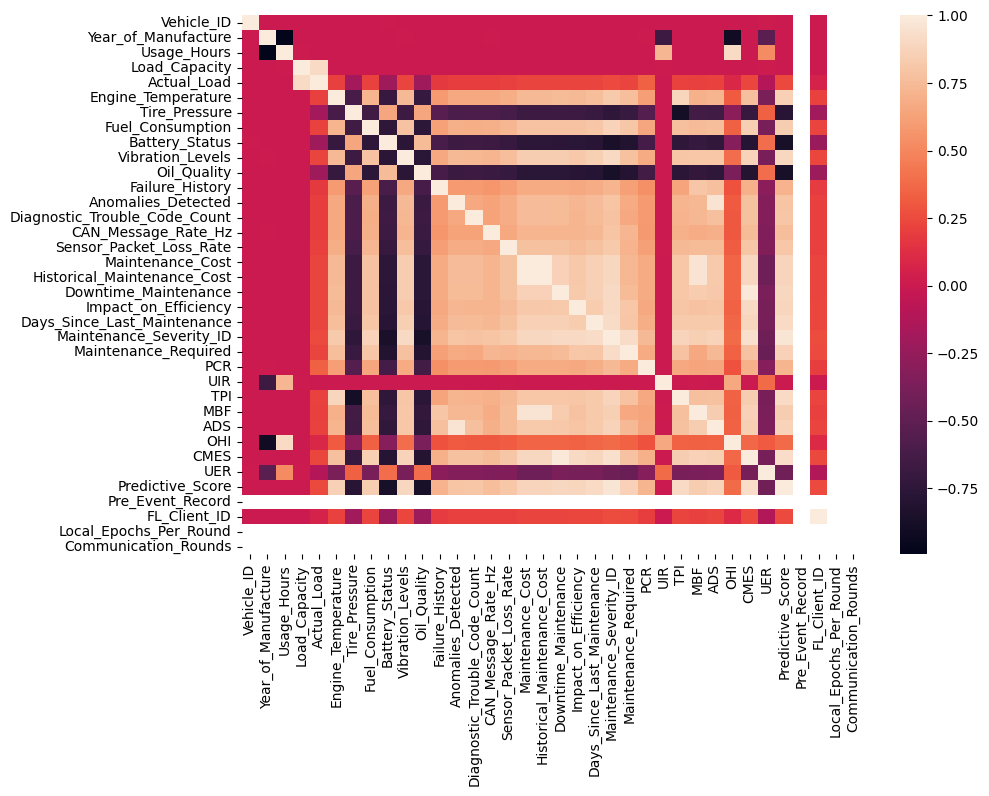

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only= True))

<Axes: >

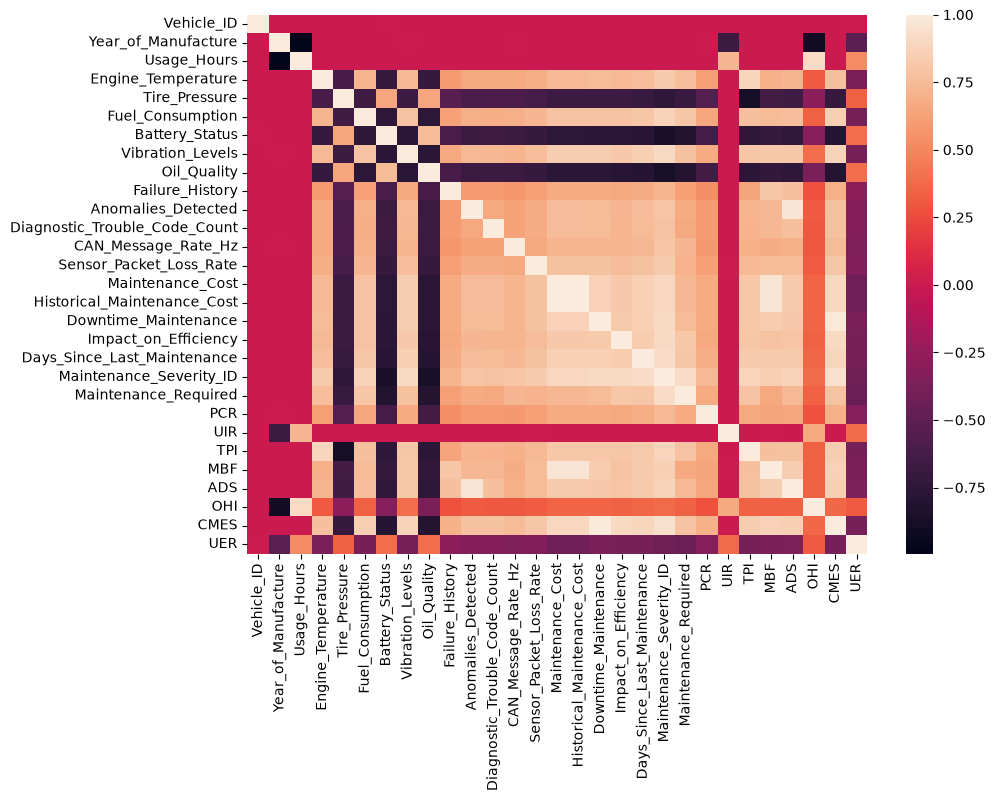

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only= True))

<Axes: >

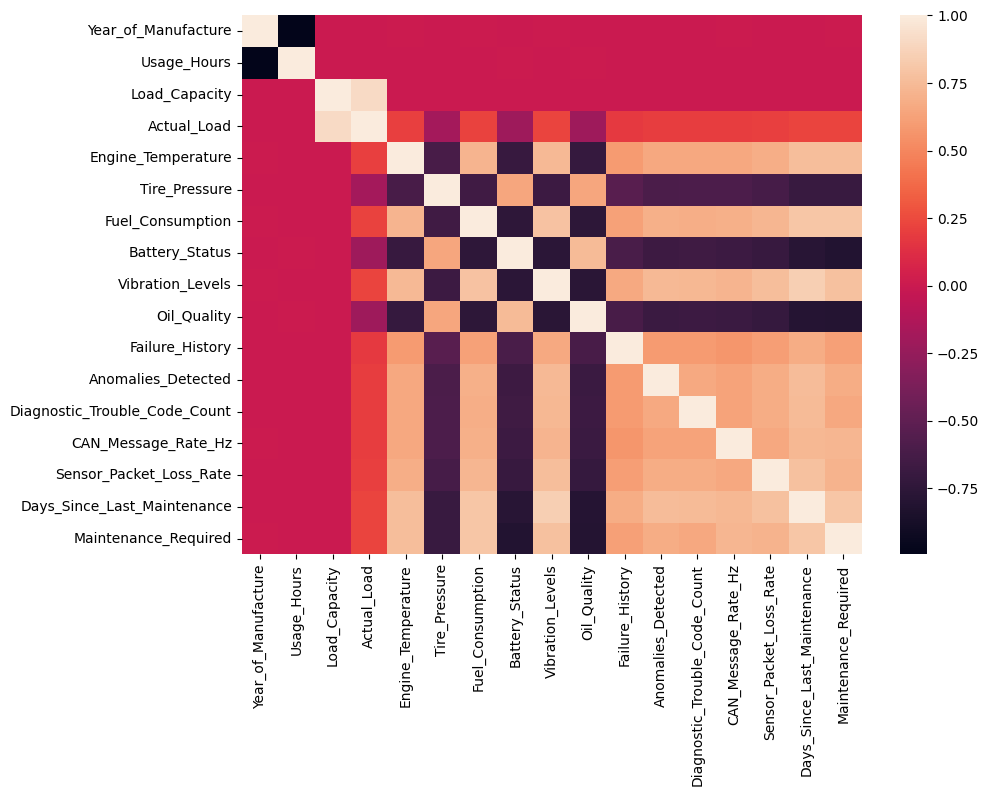

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(numeric_only= True))

## Histogram

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Vehicle_ID                     250000 non-null  int64         
 1   Make_and_Model                 250000 non-null  str           
 2   Vehicle_Type                   250000 non-null  str           
 3   Year_of_Manufacture            250000 non-null  int64         
 4   Route_Info                     250000 non-null  str           
 5   Weather_Conditions             250000 non-null  str           
 6   Road_Conditions                250000 non-null  str           
 7   Usage_Hours                    250000 non-null  float64       
 8   Engine_Temperature             250000 non-null  float64       
 9   Tire_Pressure                  250000 non-null  float64       
 10  Fuel_Consumption               250000 non-null  float64       
 11  Battery_Sta

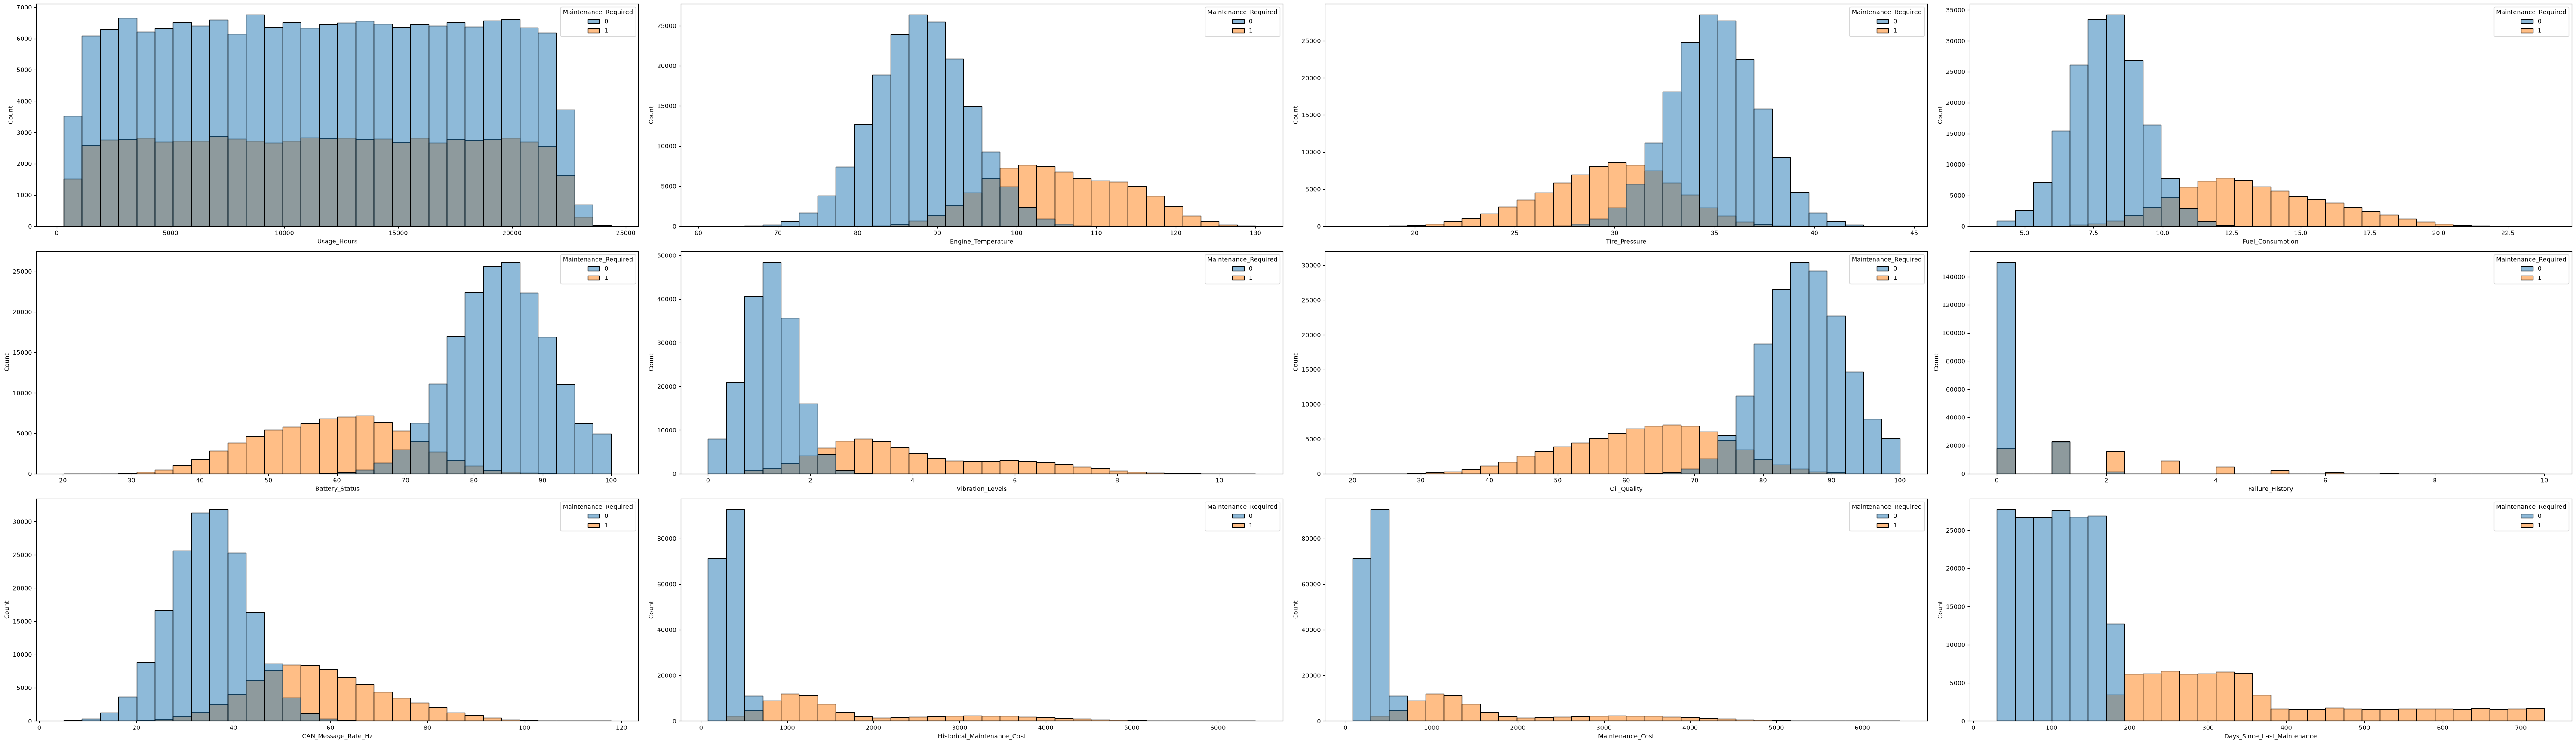

In [ ]:
plt.figure(figsize=(60, 40))

for i in range(0, len(NUM)):
    plt.subplot(7, 4, i+1)
    sns.histplot(data=df, x=NUM[i], hue='Maintenance_Required', bins=30)
    plt.xlabel(NUM[i])
    plt.tight_layout()

In [ ]:
plt.figure(figsize=(20, 5))

for i in range (9,12):
  plt.subplot(1, 3, i-8)
  plt.title("Hue: " + NUM[i])
  sns.countplot(data=df, x='Maintenance_Required', hue = NUM[i],palette="pastel")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.xlabel('Maintenance_Required')
  plt.tight_layout()

## Boxplot for outlier

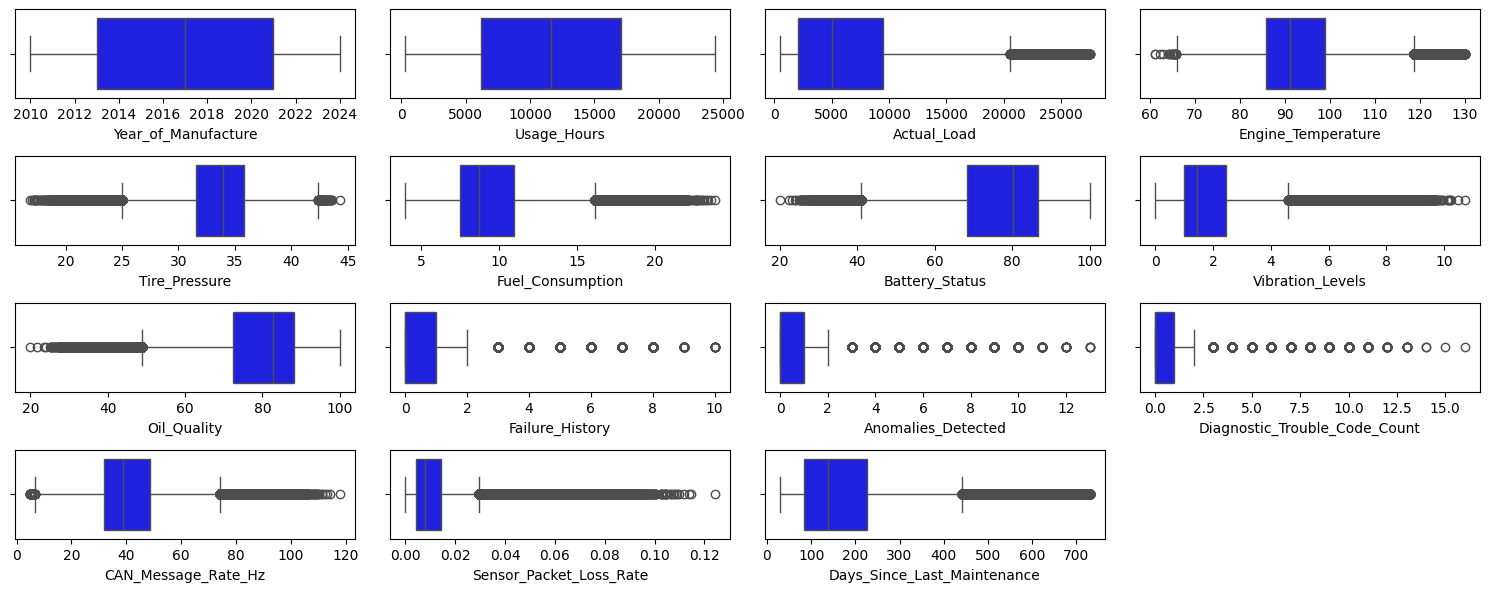

In [ ]:
plt.figure(figsize=(15, 10))

for i in range(0, len(NUM)):
    plt.subplot(7, 4, i+1)
    sns.boxplot(x=df[NUM[i]], color='blue')
    plt.xlabel(NUM[i])
    plt.tight_layout()